<a href="https://colab.research.google.com/github/Matheus0820/Sinais-e-Sistemas/blob/main/unidade01/Trabalho03_Unidade_1_Sinais_e_Sistemas_Calculo_da_convolucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 3 - Unidade 1
### Objetivo:
1. Rotinas para calcular a convolução de dois sinais finitos (representados  por arrays);

2. Rotinas para implementação da convolução entre dois sinais exponenciais (podendo ser complexos), segundo àquelas fórmulas que obtivemos em sala de aula.

#### **Aluno:** Matheus Ramos Ferreira da Silva.

# Definindo Sinais Finitos Aleatoriamente

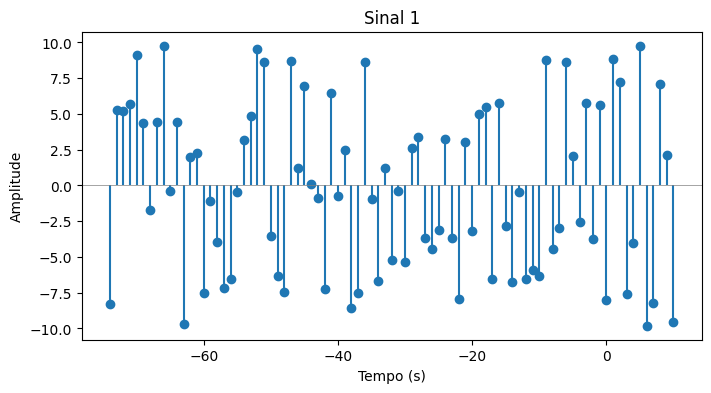

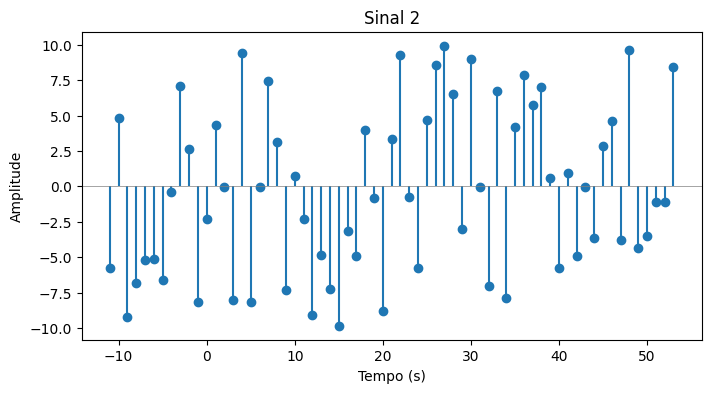

In [88]:
# Importando bibliotecas necessária
import numpy as np
import random
import matplotlib.pyplot as plt

# Tamanho mínimo e máximo do sinal
tam_min = 20
tam_max = 100

# Espaçamento de tempo (t) entre cada valor do sinal
t = 1

# == Gerando e plotando Sinal 1 ==
s1_tam = random.randint(tam_min, tam_max)
s1_0 = random.randint(0, s1_tam)
s1 = (np.random.default_rng().uniform(-10, 10, size = s1_tam)).tolist()

# Plotando Sinal 1

T1 = []
for i in range(s1_tam):
    T1.append((i - s1_0)*t)

plt.figure(figsize=(8, 4))
plt.plot(T1, s1, 'o')
plt.title('Sinal 1')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.vlines(T1, 0, s1)
plt.axhline(0, color='gray', linewidth=0.5)
plt.show()


# == Gerando e plotando Sinal 2 ==
s2_tam = random.randint(tam_min, tam_max)
s2_0 = random.randint(0, s2_tam)
s2 = (np.random.default_rng().uniform(-10, 10, size = s2_tam)).tolist()

# Plotando Sinal 2
T2 = []
for i in range(s2_tam):
    T2.append((i - s2_0)*t)

plt.figure(figsize=(8, 4))
plt.plot(T2, s2, 'o')
plt.title('Sinal 2')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.vlines(T2, 0, s2)
plt.axhline(0, color='gray', linewidth=0.5)
plt.show()






# Convolução com dois sinais finitos
## Função de convolução
$$
(u * h)(k) = \sum_{n ~ = ~ -\infty}^{k}u(n) \cdot h_{k}(n) ~ = ~ \sum_{n ~ = ~ -\infty}^{k}u(n) \cdot h(k - n) \tag{1}
$$

- $\infty$: Maior index do sinal $u$
- $-\infty$: Primeiro index do sinal $u$
- $k \in ℕ \Rightarrow k ~ \in ~[\text{menor } i_0, i_{tam}]$

## Lógica do código:
- **Entradas:** sinal 1 (lista), posição inicial do sinal 1 (int), sinal 2 (lista), posição inicial do sinal 2 (int)
- **Saída:** Sinal de convolução (lista)




In [89]:
# Funções auxíliares
def addZerosAtras(sinal, dif_tam):
  for i in range(dif_tam):
    sinal.append(0)

def addZerosFrente(sinal, dif_inicio):
  for i in range(dif_inicio):
    sinal.insert(0, 0)

In [90]:
def convolucao(u, u_0, f, f_0):
  f_tam = len(f)
  u_tam = len(u)

  aling_u_f = []

  # Alinhando sinais
  u_copy = u.copy()
  f_copy = f.copy()

  aling_u_f_index_fim = max(u_0 + (u_tam - 1), f_0 + (f_tam -1))
  aling_u_f_0 = min(u_0, f_0)
  aling_u_f_tam = aling_u_f_index_fim - aling_u_f_0 + 1

  # Alinhar os inicios do sinais
  if u_0 > aling_u_f_0:
    addZerosFrente(u_copy, u_0 - aling_u_f_0)

  if f_0 > aling_u_f_0:
    addZerosFrente(f_copy, f_0 - aling_u_f_0)

  # Alinhando o final dos sinais
  if len(u_copy) < aling_u_f_tam:
    addZerosAtras(u_copy, aling_u_f_tam - len(u_copy))

  if len(f_copy) < aling_u_f_tam:
    addZerosAtras(f_copy, aling_u_f_tam - len(f_copy))

  # == Fazendo a convolução com sinais alinhados ==
  conv_np = np.convolve(u_copy, f_copy)
  return aling_u_f_0, conv_np



In [91]:
# Testando convolução
conv_0, conv_np = convolucao(s1, s1_0, s2, s2_0)
print(f"(s1 * s2)(0) tá na posição {conv_0}")
print(f"(s1 * s2) = {conv_np.tolist()}")

(s1 * s2)(0) tá na posição 11
(s1 * s2) = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 48.0393873656117, -70.5895677553026, 72.19172185274493, 0.2086462954563828, -65.93397733308058, -53.99971376242199, -90.23562163094685, -223.73960209437334, -220.41874816533587, -73.00258627515834, -105.73144039388583, -2.81317525316566, -171.47205137934637, -2.1573380239402127, 15.518718575087483, -165.47885324546928, 281.19737587733334, 92.78353523572099, -125.69967496893682, 52.288825617826376, 255.1485238033241, 116.7639503698021, 65.28198200128358, 66.92002514957392, -195.16224971089403, -86.58841676560482, -267.3429994685525, -198.11328202728964, 12.697369324254812, -383.9367939199976, -77.02856031450746, 26.4924114804449, -324.



---



# Obtendo dois sinais exponenciais finitos
## Tipos de sinais exponenciais
Um sinal exponencial pode aparecer de várias formas, entre elas a sua forma real ou imaginária. Segue abaixo algumas exemplificações.

$$
u = (1, 2, 4, 8, 16, 32, ..., a^n) \tag{2}
$$
$$
u = (1, (\alpha - j\beta)^1, (\alpha - j\beta)^2, ..., (\alpha - j\beta)^n) \tag{3}
$$
$$
u = (1, (\alpha + j\beta)^1, (\alpha + j\beta)^2, ..., (\alpha + j\beta)^n) \tag{4}
$$

De forma geral, a forma desses sinais de caracter exponencial são definidas como:
$$
u(k) =
\begin{cases}
    0, & \text{se } x < 0 \\
    a^k, & \text{se } x \geq 0
\end{cases}
\tag{5}
$$

Onde $a$ pode ser definido como um número complexo ou um número real (que é um complexo com parte imaginária igual a zero). Dessa forma, podemos definir $a$ de forma geral como:
$$
a = \alpha +j\beta, \text{ onde: }
\begin{cases}
    a \in \mathbb{R}, & \text{se } \beta = 0 \\
    a \in \mathbb{C}, & \text{se } \beta \neq 0
\end{cases}
$$

## Gerando funções auxíliares para o calculo da convolução dos sinais exponenciais

In [92]:
# == Funções Auxíliares ==

# Função que gera um sinal exponencial
def sinal_exponencial(a, N): # a = base e N = tamanho do sinal (numero de pontos)
    u = []

    for k in range(N):
        u.append(a**k)

    return u

# Função da convolução
def convolucao_exponenciais(a, b, K):
    conv_exp = []

    for k in range(K):
        if a != b:
            val = (a**(k+1) - b**(k+1)) / (a - b)
        else:
            val = (k+1) * (a**k)

        conv_exp.append(val)

    return conv_exp

## Gerando sinais exponenciais aleatoriamente

Sinal 1: a = -5.436 1.259j
Sinal 1: [(1+0j), (-5.435680103546501+1.258506699027759j), (27.962779076593552-13.681679648170347j), (-134.77823637533183+109.56057863798287j), (594.7286556912195-765.1555707970272j), (-2269.8013091032517+4907.610909590339j), (6161.65260895519-29532.763130176376j), (3674.4077486638416+168285.13403490337j), (-231760.8736214394-910119.8880295274j), (2405169.9455281673+4655447.955178964j), (-18932646.857123286-22278603.334315106j), (130949583.36995496+97272497.97912486j), (-834218135.2296607-363941253.98141396j), (4992565425.873703+928399121.4895623j), (-28306385064.841953+1236696400.9655695j), (152308063395.00854-42346061250.218994j), (-774605108045.1067+421860360699.9397j), (3679591483911.1333-3267943686707.5j), (-15888353196508.03+22394287009534.01j), (58180645126929.28-141723779265158.34j), (-137891049511216+843585858797034.6j), (-312126820215890.75-4758999677842062j), (7685854521665938+2.5475586167442376e+16j), (-7.383904235555757e+16-1.288044374532816e+17j

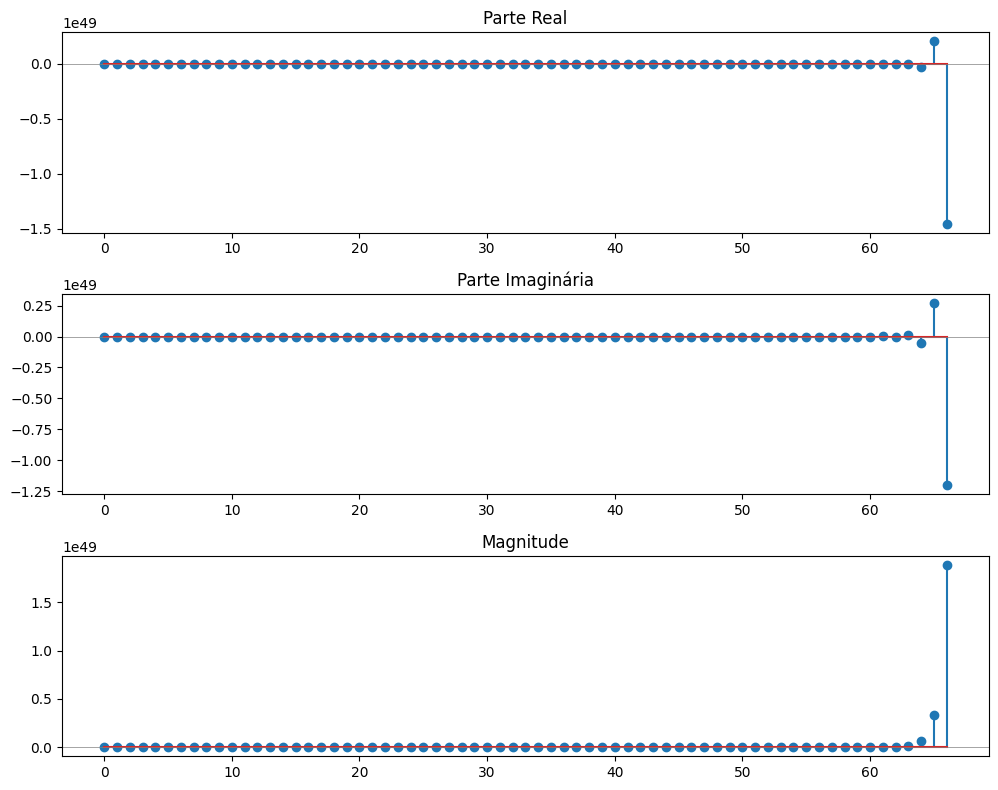

In [93]:
# == Gerando sinal exponencial 1 ==
alpha = random.uniform(-10, 10)
beta = random.uniform(-10, 10)
a = complex(alpha, beta)
print(f"Sinal 1: a = {a.real:.3f} {a.imag:.3f}j")

sExp1_tam = random.randint(tam_min, tam_max)
sExp1 = sinal_exponencial(a, sExp1_tam)
print(f"Sinal 1: {sExp1}", end="\n\n")

# Plotando sinal exponencial 1
T_Exp1 = []
for i in range(sExp1_tam):
    T_Exp1.append(i * t)

# Separando componentes
s1_real = np.real(sExp1)
s1_imag = np.imag(sExp1)
s1_mag = np.abs(sExp1)

# Plotando
plt.figure(figsize=(10, 8))

# Parte real
plt.subplot(3, 1, 1)
plt.stem(T_Exp1, s1_real)
plt.title('Parte Real')
plt.axhline(0, color='gray', linewidth=0.5)

# Parte imaginária
plt.subplot(3, 1, 2)
plt.stem(T_Exp1, s1_imag)
plt.title('Parte Imaginária')
plt.axhline(0, color='gray', linewidth=0.5)

# Magnitude
plt.subplot(3, 1, 3)
plt.stem(T_Exp1, s1_mag)
plt.title('Magnitude')
plt.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()


Sinal 2: b = 2.289 -4.159j
Sinal 2: [(1+0j), (2.2890596783852164-4.1591964923320335j), (-12.059121250618059-19.04129797015697j), (-106.80054793847404+6.569587398572729j), (-217.14862305119584+459.2426419825408j), (1413.0142284197166+1954.3976056665965j), (11363.197561370804-1403.2710677945233j), (20174.557252297123-50473.94265806238j), (-163750.2797220738-199447.81470580408j), (-1204376.8139637692+224521.6384533366j), (-1823060.7913187586+5523183.249592654j), (18798909.449559998+20225364.12153622j), (127153089.1290342-31891292.75100986j), (158418856.3614596-601855754.6225768j), (-2140606127.1231542-2036578891.8084826j), (-13370506956.069252+4241350872.3058357j), (-12965276681.863342+65319270896.06353j), (241997390321.03186+203444842527.02032j), (1400113543879.7488-540817311172.7095j), (955577994834.1882-7061310440949.384j), (-27182002559737.098-20138197651201.797j), (-145979947070025.62+66957753462300.984j), (-55666357355968.484+760429577410277.8j), (3035352416964228.5+1972196002157222

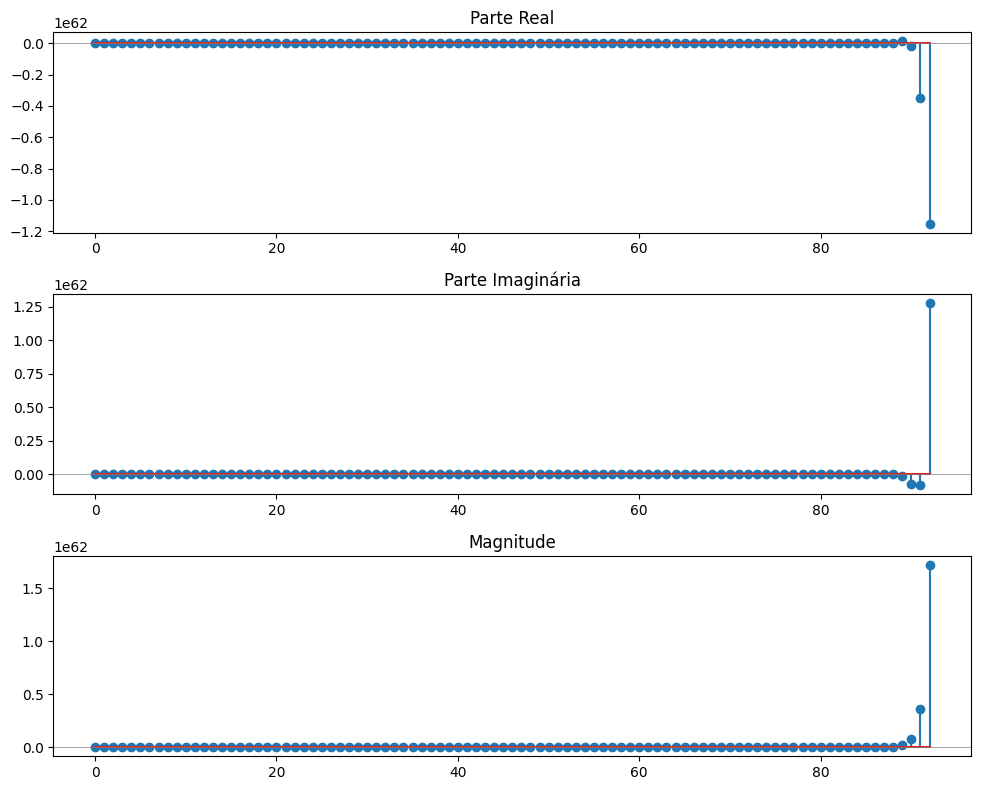

In [94]:
# == Gerando Sinal Exponencial 2 ==
alpha = random.uniform(-10, 10)
beta = random.uniform(-10, 10)
b = complex(alpha, beta)
print(f"Sinal 2: b = {b.real:.3f} {b.imag:.3f}j")

sExp2_tam = random.randint(tam_min, tam_max)
sExp2 = sinal_exponencial(b, sExp2_tam)
print(f"Sinal 2: {sExp2}", end="\n\n")

# Plotando o Sinal exponencial 2
T_Exp2 = []
for i in range(sExp2_tam):
    T_Exp2.append(i * t)

# plt.plot(T_Exp2, sExp2, 'o')
# plt.title('Sinal Exponencial 2')
# plt.xlabel('Tempo (s)')
# plt.ylabel('Amplitude')
# plt.vlines(T_Exp2, 0, sExp2)
# plt.axhline(0, color='gray', linewidth=0.5)
# plt.show()

# Separando componentes
s2_real = np.real(sExp2)
s2_imag = np.imag(sExp2)
s2_mag = np.abs(sExp2)

# Plotando
plt.figure(figsize=(10, 8))

# Parte real
plt.subplot(3, 1, 1)
plt.stem(T_Exp2, s2_real)
plt.title('Parte Real')
plt.axhline(0, color='gray', linewidth=0.5)

# Parte imaginária
plt.subplot(3, 1, 2)
plt.stem(T_Exp2, s2_imag)
plt.title('Parte Imaginária')
plt.axhline(0, color='gray', linewidth=0.5)

# Magnitude
plt.subplot(3, 1, 3)
plt.stem(T_Exp2, s2_mag)
plt.title('Magnitude')
plt.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

## Convolução entre Sinal exponencial 1 e 2

(sExp1 * sExp2)(0) tá na posição 0
(sExp1 * sExp2) = [(1-0j), (-3.1466204251612844-2.900689793304275j), (8.695438324519039-7.234119058495563j), (-144.96198173399685+56.835211813913524j), (499.2908420224903-32.13101317177462j), (-1260.5339721216858+2757.4123841197174j), (14744.835036080327-17978.073149694002j), (-37348.12368889906+65805.58553079917j), (-43554.59710548635-604148.7905363934j), (-207302.65695992348+3453667.4465229833j), (-5042693.481132645-13510739.95624889j), (63212734.816997595+87319160.95876j), (-326342864.82656336-426976668.4018592j), (2469667271.1458697+1308348144.9238408j), (-17211492280.317932-6040248066.576298j), (87787351839.97487+15413428773.235168j), (-509547141787.5547+92017773166.47322j), (2895927666795.0073-938002827656.7185j), (-13160740013514.754+8202410364752.613j), (62170362242028.75-68209868732929.766j), (-279277626888815.22+428870646048478.7j), (832347311706817.2-2615718648586698j), (-1288140636822937.5+1.6026154059709306e+16j), (-1.0131749396682696e+16

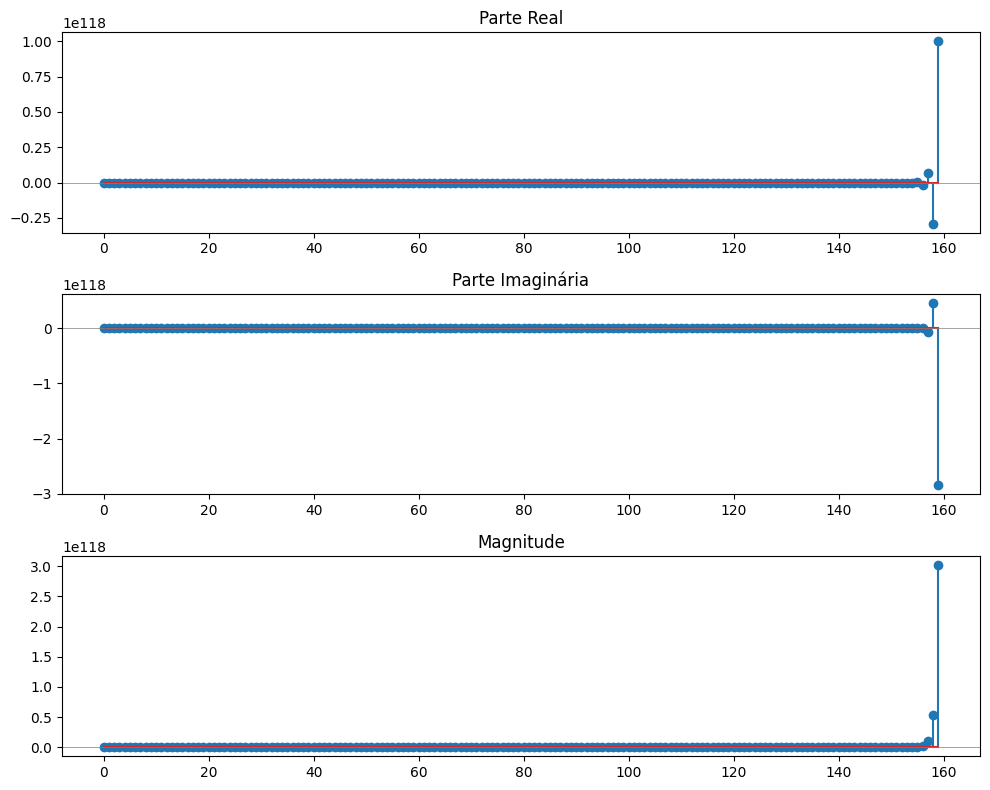

In [95]:
# == Fazendo convolução ==
conv_exp = convolucao_exponenciais(a, b, sExp1_tam + sExp2_tam)
print(f"(sExp1 * sExp2)(0) tá na posição {0}")
print(f"(sExp1 * sExp2) = {conv_exp}", end="\n\n")

# Plotando a convolução dos dois sinais
T_conv = []
for i in range(len(conv_exp)):
    T_conv.append(i * t)

# Separando componentes
conv_real = np.real(conv_exp)
conv_imag = np.imag(conv_exp)
conv_mag = np.abs(conv_exp)

# Plotando
plt.figure(figsize=(10, 8))

# Parte real
plt.subplot(3, 1, 1)
plt.stem(T_conv, conv_real)
plt.title('Parte Real')
plt.axhline(0, color='gray', linewidth=0.5)

# Parte imaginária
plt.subplot(3, 1, 2)
plt.stem(T_conv, conv_imag)
plt.title('Parte Imaginária')
plt.axhline(0, color='gray', linewidth=0.5)

# Magnitude
plt.subplot(3, 1, 3)
plt.stem(T_conv, conv_mag)
plt.title('Magnitude')
plt.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()